# SML Exp - 4

**Ridge and Lasso Regression Model**

In [8]:
# Importing the necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
from sklearn.model_selection import train_test_split
import operator
from sklearn.model_selection import GridSearchCV

In [9]:
# Loading the dataset
df=pd.read_csv(r"C:\Users\Yug\Downloads\Advertising.csv")
df.head()

,Unnamed: 0,TV,Radio,Newspaper,Sales
0,1,230.1,37.8,69.2,22.1
1,2,44.5,39.3,45.1,10.4
2,3,17.2,45.9,69.3,9.3
3,4,151.5,41.3,58.5,18.5
4,5,180.8,10.8,58.4,12.9


In [10]:
# Transforming into X and Y
x=df[['TV','Radio','Newspaper']]
y=df['Sales']
print(x)
print(y)

        TV  Radio  Newspaper
0    230.1   37.8       69.2
1     44.5   39.3       45.1
2     17.2   45.9       69.3
3    151.5   41.3       58.5
4    180.8   10.8       58.4
..     ...    ...        ...
195   38.2    3.7       13.8
196   94.2    4.9        8.1
197  177.0    9.3        6.4
198  283.6   42.0       66.2
199  232.1    8.6        8.7

[200 rows x 3 columns]
0      22.1
1      10.4
2       9.3
3      18.5
4      12.9
       ... 
195     7.6
196     9.7
197    12.8
198    25.5
199    13.4
Name: Sales, Length: 200, dtype: float64


In [11]:
# Train-Test split
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

In [ ]:
# Different alpha values to observe behaviour
alpha_values=[0,0.1,1,10,100]
print("RIDGE REGRESSION COEFFICIENTS\n")
for alpha_value in alpha_values:
  # Create ridge model with specific alpha
  ridge_model = Ridge(alpha=alpha_value)

  # Train model
  ridge_model.fit(x_train, y_train)

  # Print coefficients
  print(f"Alpha = {alpha_value}")
  print(pd.Series(ridge_model.coef_, index=x.columns))
  print("-"*40)

RIDGE REGRESSION COEFFICIENTS

Alpha = 0
TV           0.044730
Radio        0.189195
Newspaper    0.002761
dtype: float64
----------------------------------------
Alpha = 0.1
TV           0.044730
Radio        0.189194
Newspaper    0.002761
dtype: float64
----------------------------------------
Alpha = 1
TV           0.044730
Radio        0.189189
Newspaper    0.002763
dtype: float64
----------------------------------------
Alpha = 10
TV           0.044730
Radio        0.189131
Newspaper    0.002779
dtype: float64
----------------------------------------
Alpha = 100
TV           0.044731
Radio        0.188561
Newspaper    0.002936
dtype: float64
----------------------------------------


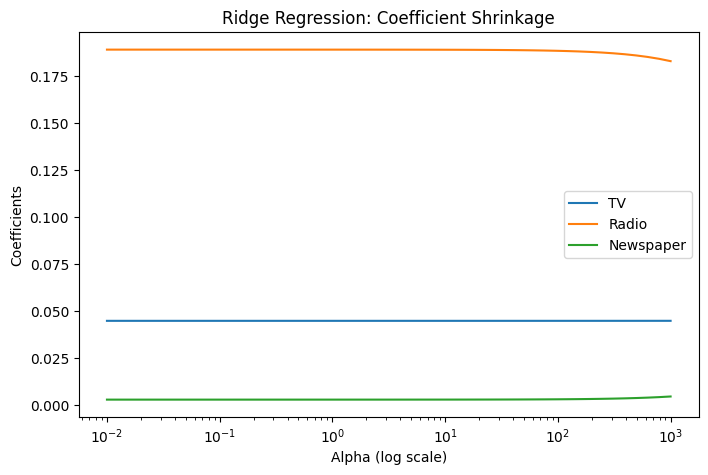

In [13]:
# Generate alpha values on log scale
alphas=np.logspace(-2,3,50)

# Store coefficients
coefficients_path=[]

for alpha_value in alphas:
  ridge=Ridge(alpha=alpha_value)
  ridge.fit(x_train,y_train)
  coefficients_path.append(ridge.coef_)

# Convert to numpy array
coefficients_path=np.array(coefficients_path)

# Plot
plt.figure(figsize=(8,5))
plt.plot(alphas,coefficients_path)
plt.xscale("log")
plt.xlabel("Alpha (log scale)")
plt.ylabel("Coefficients")
plt.title("Ridge Regression: Coefficient Shrinkage")
plt.legend(x.columns)
plt.show()

In [16]:
# Lasso Regression
print("LASSO REGRESSION COEFFICIENTS\n")
for alpha_value in [0.001,0.01,0.1,1]:
  lasso_model = Lasso(alpha=alpha_value, max_iter=5000)
  lasso_model.fit(x_train, y_train)
  
  print(f"Alpha = {alpha_value}")
  print(pd.Series(lasso_model.coef_, index=x.columns))
  print("-"*40)

LASSO REGRESSION COEFFICIENTS

Alpha = 0.001
TV           0.044729
Radio        0.189191
Newspaper    0.002760
dtype: float64
----------------------------------------
Alpha = 0.01
TV           0.044728
Radio        0.189157
Newspaper    0.002748
dtype: float64
----------------------------------------
Alpha = 0.1
TV           0.044720
Radio        0.188811
Newspaper    0.002627
dtype: float64
----------------------------------------
Alpha = 1
TV           0.044631
Radio        0.185350
Newspaper    0.001422
dtype: float64
----------------------------------------


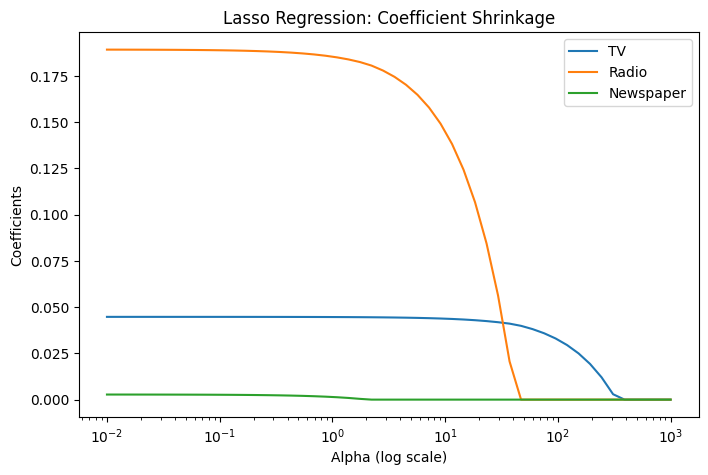

In [21]:
# Generate alpha values on log scale
alphas=np.logspace(-2,3,50)

# Store coefficients
coefficients_path=[]

for alpha_value in alphas:
  lasso=Lasso(alpha=alpha_value)
  lasso.fit(x_train,y_train)
  coefficients_path.append(lasso.coef_)

# Convert to numpy array
coefficients_path=np.array(coefficients_path)

# Plot
plt.figure(figsize=(8,5))
plt.plot(alphas,coefficients_path)
plt.xscale("log")
plt.xlabel("Alpha (log scale)")
plt.ylabel("Coefficients")
plt.title("Lasso Regression: Coefficient Shrinkage")
plt.legend(x.columns)
plt.show()

In [22]:
# Define alpha search space
param_grid={'alpha':np.logspace(-3,2,20)}

# Gridsearch for Ridge
ridge_cv=GridSearchCV(
    Ridge(),
    param_grid,
    scoring='neg_mean_squared_error'
)
ridge_cv.fit(x_train,y_train)
print("Best Alpha (Ridge): ",ridge_cv.best_params_['alpha'])

Best Alpha (Ridge):  0.001


In [29]:
# Define alpha search space
param_grid={'alpha':np.logspace(-3,2,20)}

# Gridsearch for Ridge
lasso_cv=GridSearchCV(
    Lasso(max_iter=5000),
    param_grid,
    scoring='neg_mean_squared_error'
)
lasso_cv.fit(x_train,y_train)
print("Best Alpha (Lasso): ",lasso_cv.best_params_['alpha'])

Best Alpha (Lasso):  1.438449888287663


In [30]:
# Best models
best_ridge=ridge_cv.best_estimator_
best_lasso=lasso_cv.best_estimator_

# Predictions
ridge_pred=best_ridge.predict(x_test)
lasso_pred=best_lasso.predict(x_test)

# Errors
print("Ridge MSE: ",mean_squared_error(y_test, ridge_pred))
print("Lasso MSE: ",mean_squared_error(y_test, lasso_pred))

Ridge MSE:  3.1740973514255284
Lasso MSE:  3.1341162711720285


In [31]:
print("Final Ridge coefficients: ")
print(pd.Series(best_ridge.coef_,index=x.columns))

print("\nFinal Lasso coefficients: ")
print(pd.Series(best_lasso.coef_,index=x.columns))

Final Ridge coefficients: 
TV           0.044730
Radio        0.189195
Newspaper    0.002761
dtype: float64

Final Lasso coefficients: 
TV           0.044587
Radio        0.183663
Newspaper    0.000835
dtype: float64


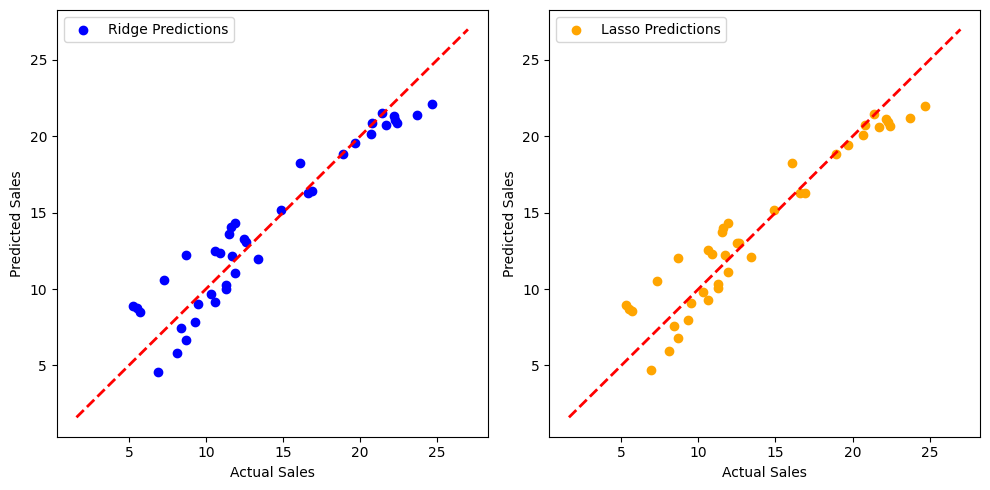

In [35]:
# Plot actual vs predicted values for both models
plt.figure(figsize=(10,5))

# Ridge regression
plt.subplot(1,2,1)
plt.scatter(y_test,ridge_pred,color='blue',label='Ridge Predictions')
plt.plot([y.min(),y.max()], [y.min(),y.max()],'r--',lw=2)
plt.xlabel("Actual Sales")
plt.ylabel("Predicted Sales")
plt.legend()

# Lasso regression
plt.subplot(1,2,2)
plt.scatter(y_test,lasso_pred,color='orange',label='Lasso Predictions')
plt.plot([y.min(),y.max()], [y.min(),y.max()],'r--',lw=2)
plt.xlabel("Actual Sales")
plt.ylabel("Predicted Sales")
plt.legend()

plt.tight_layout()